# Loan Prediction Problem¶
A Finance company wants to automate the loan eligibility process based on the customer details provided while filling application form. These details are Gender,Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers.

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data loading and cleaning

In [2]:
# Loading dataset
train = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
predict = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

In [3]:
train_original = train.copy()
predict_original = predict.copy()

In [4]:
train.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [5]:
predict.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban


## Data Cleaning - checking and working with missing value

In [6]:
# train Summary info
train.info()
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# predict Summary info
predict.info()
predict.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 34.5 KB


Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

### Bonus1 - method1 - Missing value: median/mode 

#### [Train]

In [9]:
# Clean categorical variable - fill in with mode
for col in train.columns:
    if train[col].dtype == 'str':
        train[col] = train[col].fillna(train[col].value_counts().index[0])
print(train.info())
print(train.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None
Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Se

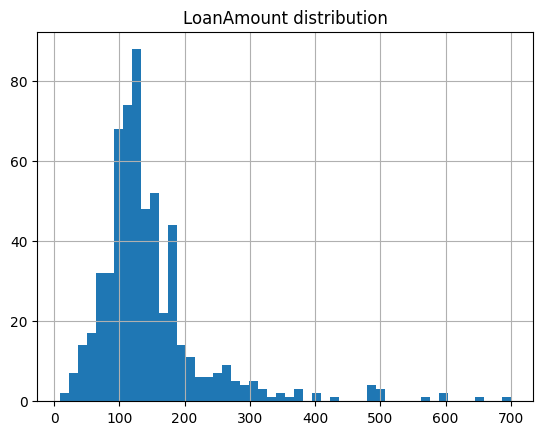

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [10]:
# Distribution of numerical variables(EDA)-LoanAmount
train['LoanAmount'].hist(bins=50)
plt.title('LoanAmount distribution')
plt.show()

train['LoanAmount'].describe()

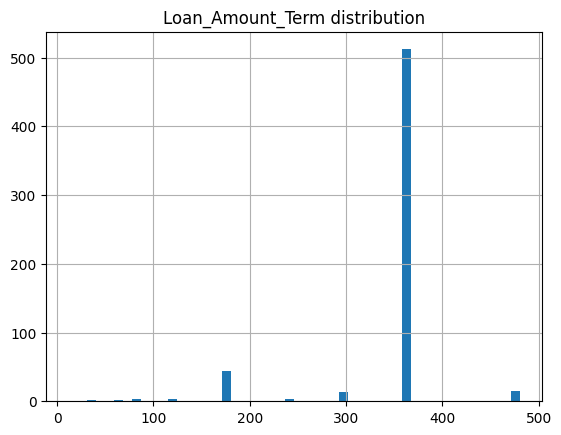

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

In [11]:
# Distribution of numerical variables(EDA)-Loan_Amount_Term
train['Loan_Amount_Term'].hist(bins=50)
plt.title('Loan_Amount_Term distribution')
plt.show()

train['Loan_Amount_Term'].describe()

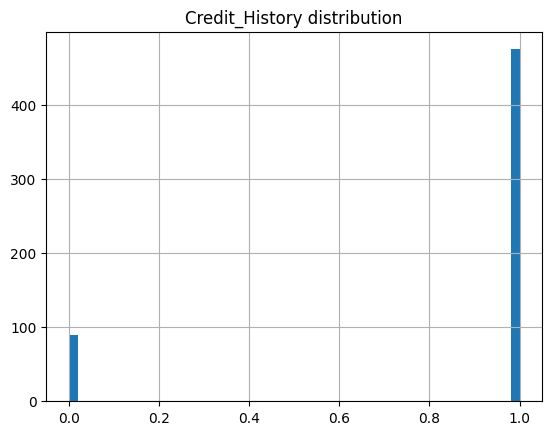

count    564.000000
mean       0.842199
std        0.364878
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Credit_History, dtype: float64

In [12]:
# Distribution of numerical variables(EDA)-Credit_History
train['Credit_History'].hist(bins=50)
plt.title('Credit_History distribution')
plt.show()

train['Credit_History'].describe()

- **LoanAmount** shows a **right-skewed** distribution with some extreme outliers. To avoid the influence of these high values on the imputation, we chose to fill missing values using the **median**, which better represents the central tendency of skewed data.  

- **Loan_Amount_Term** is technically a numerical column but represents **categorical-like duration options** (e.g., 360 months). Since most loans fall under a single dominant term (360), the distribution is highly imbalanced, and we used the **mode** for imputation.  

- **Credit_History** is a **binary** indicator (mostly 1s and some 0s), showing a sharp concentration at 1. It behaves like a categorical variable, so we also filled missing values using the **mode**.

In [13]:
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0])
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None


#### [Predict]

In [14]:
# Clean categorical variable - fill in with mode
for col in predict.columns:
    if predict[col].dtype == 'str':
        predict[col] = predict[col].fillna(train[col].value_counts().index[0])
print(predict.info())
print(predict.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             367 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         367 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      367 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 34.5 KB
None
Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
Co

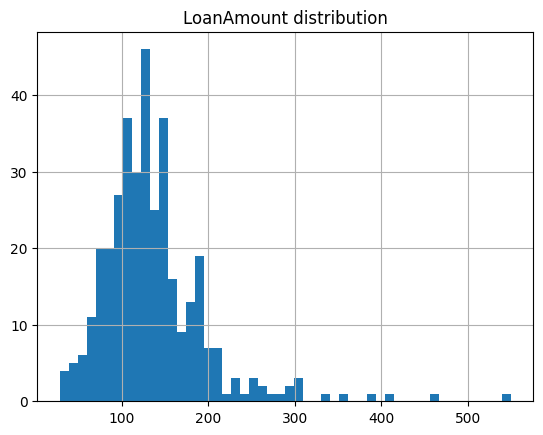

count    362.000000
mean     136.132597
std       61.366652
min       28.000000
25%      100.250000
50%      125.000000
75%      158.000000
max      550.000000
Name: LoanAmount, dtype: float64

In [15]:
# Distribution of numerical variables(EDA)-LoanAmount
predict['LoanAmount'].hist(bins=50)
plt.title('LoanAmount distribution')
plt.show()

predict['LoanAmount'].describe()

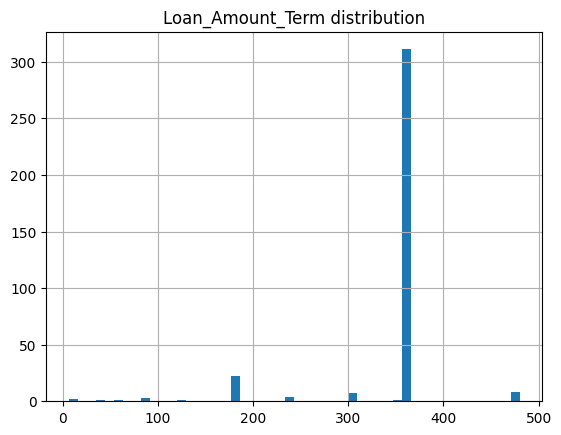

count    361.000000
mean     342.537396
std       65.156643
min        6.000000
25%      360.000000
50%      360.000000
75%      360.000000
max      480.000000
Name: Loan_Amount_Term, dtype: float64

In [16]:
# Distribution of numerical variables(EDA)-Loan_Amount_Term
predict['Loan_Amount_Term'].hist(bins=50)
plt.title('Loan_Amount_Term distribution')
plt.show()

predict['Loan_Amount_Term'].describe()

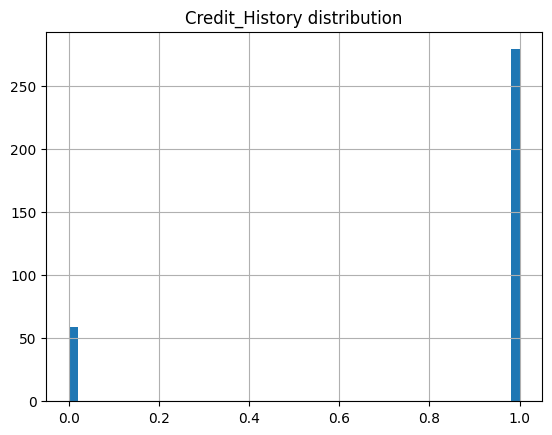

count    338.000000
mean       0.825444
std        0.380150
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Credit_History, dtype: float64

In [17]:
# Distribution of numerical variables(EDA)-Credit_History
predict['Credit_History'].hist(bins=50)
plt.title('Credit_History distribution')
plt.show()

predict['Credit_History'].describe()

In [18]:
predict['LoanAmount'] = predict['LoanAmount'].fillna(predict['LoanAmount'].median())
predict['Loan_Amount_Term'] = predict['Loan_Amount_Term'].fillna(predict['Loan_Amount_Term'].mode()[0])
predict['Credit_History'] = predict['Credit_History'].fillna(predict['Credit_History'].mode()[0])
print(predict.info())

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             367 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         367 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      367 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 34.5 KB
None


### Bonus1 - method2 - Missing value: SimpleImputer

#### [train]

In [9]:
from sklearn.impute import SimpleImputer

In [10]:
# LoanAmount - fill in with median
imputer = SimpleImputer(strategy='median')
train['LoanAmount'] = imputer.fit_transform(train[['LoanAmount']])

In [11]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [13]:
# Categorical variable + numerical discrete variable - fill with mode
imputer = SimpleImputer(strategy='most_frequent')

train['Gender'] = imputer.fit_transform(train[['Gender']]).ravel()
train['Married'] = imputer.fit_transform(train[['Married']]).ravel()
train['Dependents'] = imputer.fit_transform(train[['Dependents']]).ravel()
train['Self_Employed'] = imputer.fit_transform(train[['Self_Employed']]).ravel()
train['Loan_Amount_Term'] = imputer.fit_transform(train[['Loan_Amount_Term']]).ravel()
train['Credit_History'] = imputer.fit_transform(train[['Credit_History']]).ravel()

In [14]:
train.info()
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#### [predict]

In [22]:
# LoanAmount - fill in with median
imputer = SimpleImputer(strategy='median')
predict['LoanAmount'] = imputer.fit_transform(predict[['LoanAmount']])

In [23]:
# Categorical variable + numerical discrete variable - fill with mode
imputer = SimpleImputer(strategy='most_frequent')

predict['Gender'] = imputer.fit_transform(predict[['Gender']]).ravel()
predict['Married'] = imputer.fit_transform(predict[['Married']]).ravel()
predict['Dependents'] = imputer.fit_transform(predict[['Dependents']]).ravel()
predict['Self_Employed'] = imputer.fit_transform(predict[['Self_Employed']]).ravel()
predict['Loan_Amount_Term'] = imputer.fit_transform(predict[['Loan_Amount_Term']]).ravel()
predict['Credit_History'] = imputer.fit_transform(predict[['Credit_History']]).ravel()

# Exploratory Data Analysis

## EDA step1- Univariate distribution

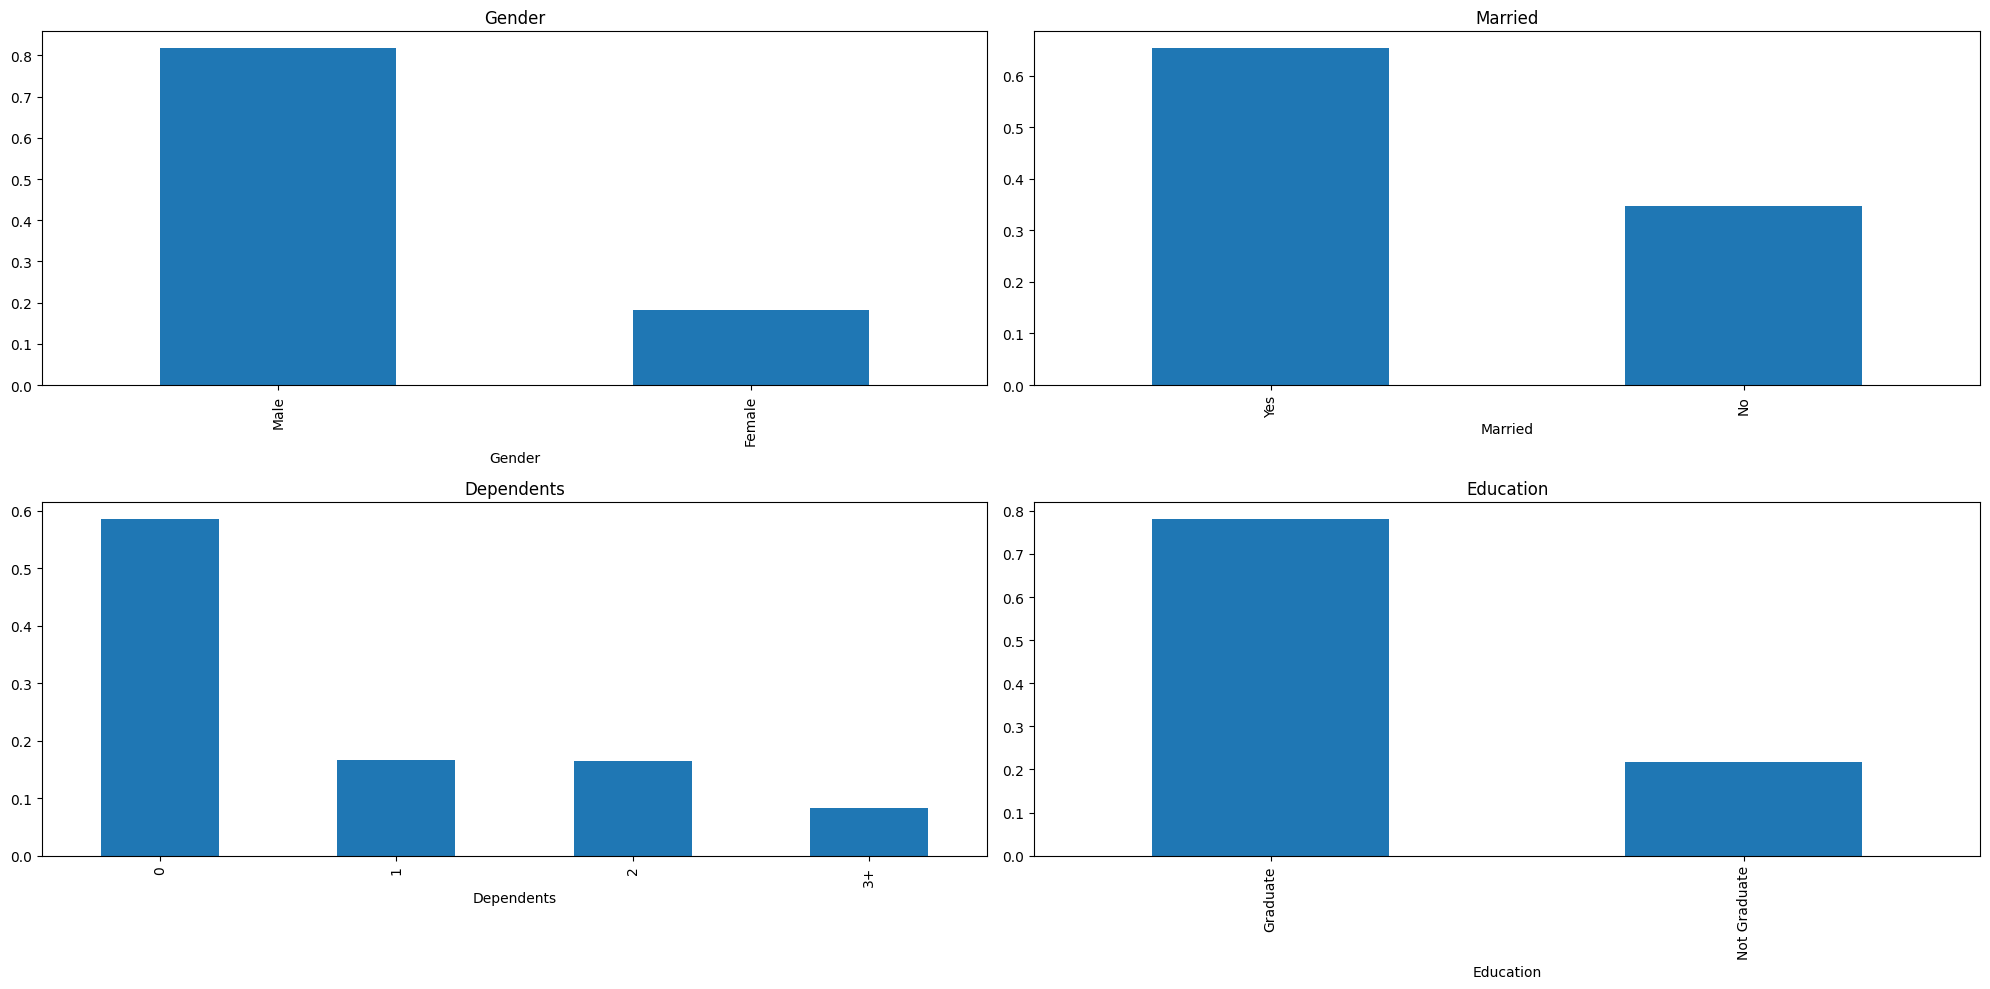

In [19]:
# categorical variable: Gender/Married/Dependents/Education
plt.figure(1)
plt.subplot(221)
train['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender')
plt.subplot(222)
train['Married'].value_counts(normalize=True).plot.bar(title= 'Married')
plt.subplot(223)
train['Dependents'].value_counts(normalize=True).plot.bar(title= 'Dependents')
plt.subplot(224)
train['Education'].value_counts(normalize=True).plot.bar(title= 'Education')

plt.tight_layout()
plt.show()

**[Gender]**  
- The proportion of male applicants is significantly higher than that of female applicants, approximately 80%+.  
- This may reflect that in this loan sample group, men are usually the primary borrowers in their families, or women tend to borrow less.

**[Married]**  
- The proportion of married applicants is significantly higher, approximately 65%:35%.  
- Married individuals may have a greater need for loans (for home purchases, family expenses, etc.), or loan companies may have a preference for marital status.  

**[Dependents]**
- The largest proportion of applicants are those with no dependents (Dependents = 0), approaching 60%; those with 1–3 dependents are more evenly distributed but represent a lower percentage.  
- Most loan applicants have no family burdens, which may make approval easier; it may also indicate that the majority are young, single applicants.

**[Education]**
- The proportion of applicants with higher education (Graduate) is significantly higher, approaching 80%.  
- Higher education levels may indicate a better understanding of the loan process, stronger credit awareness, and a better fit for the bank's target demographic.

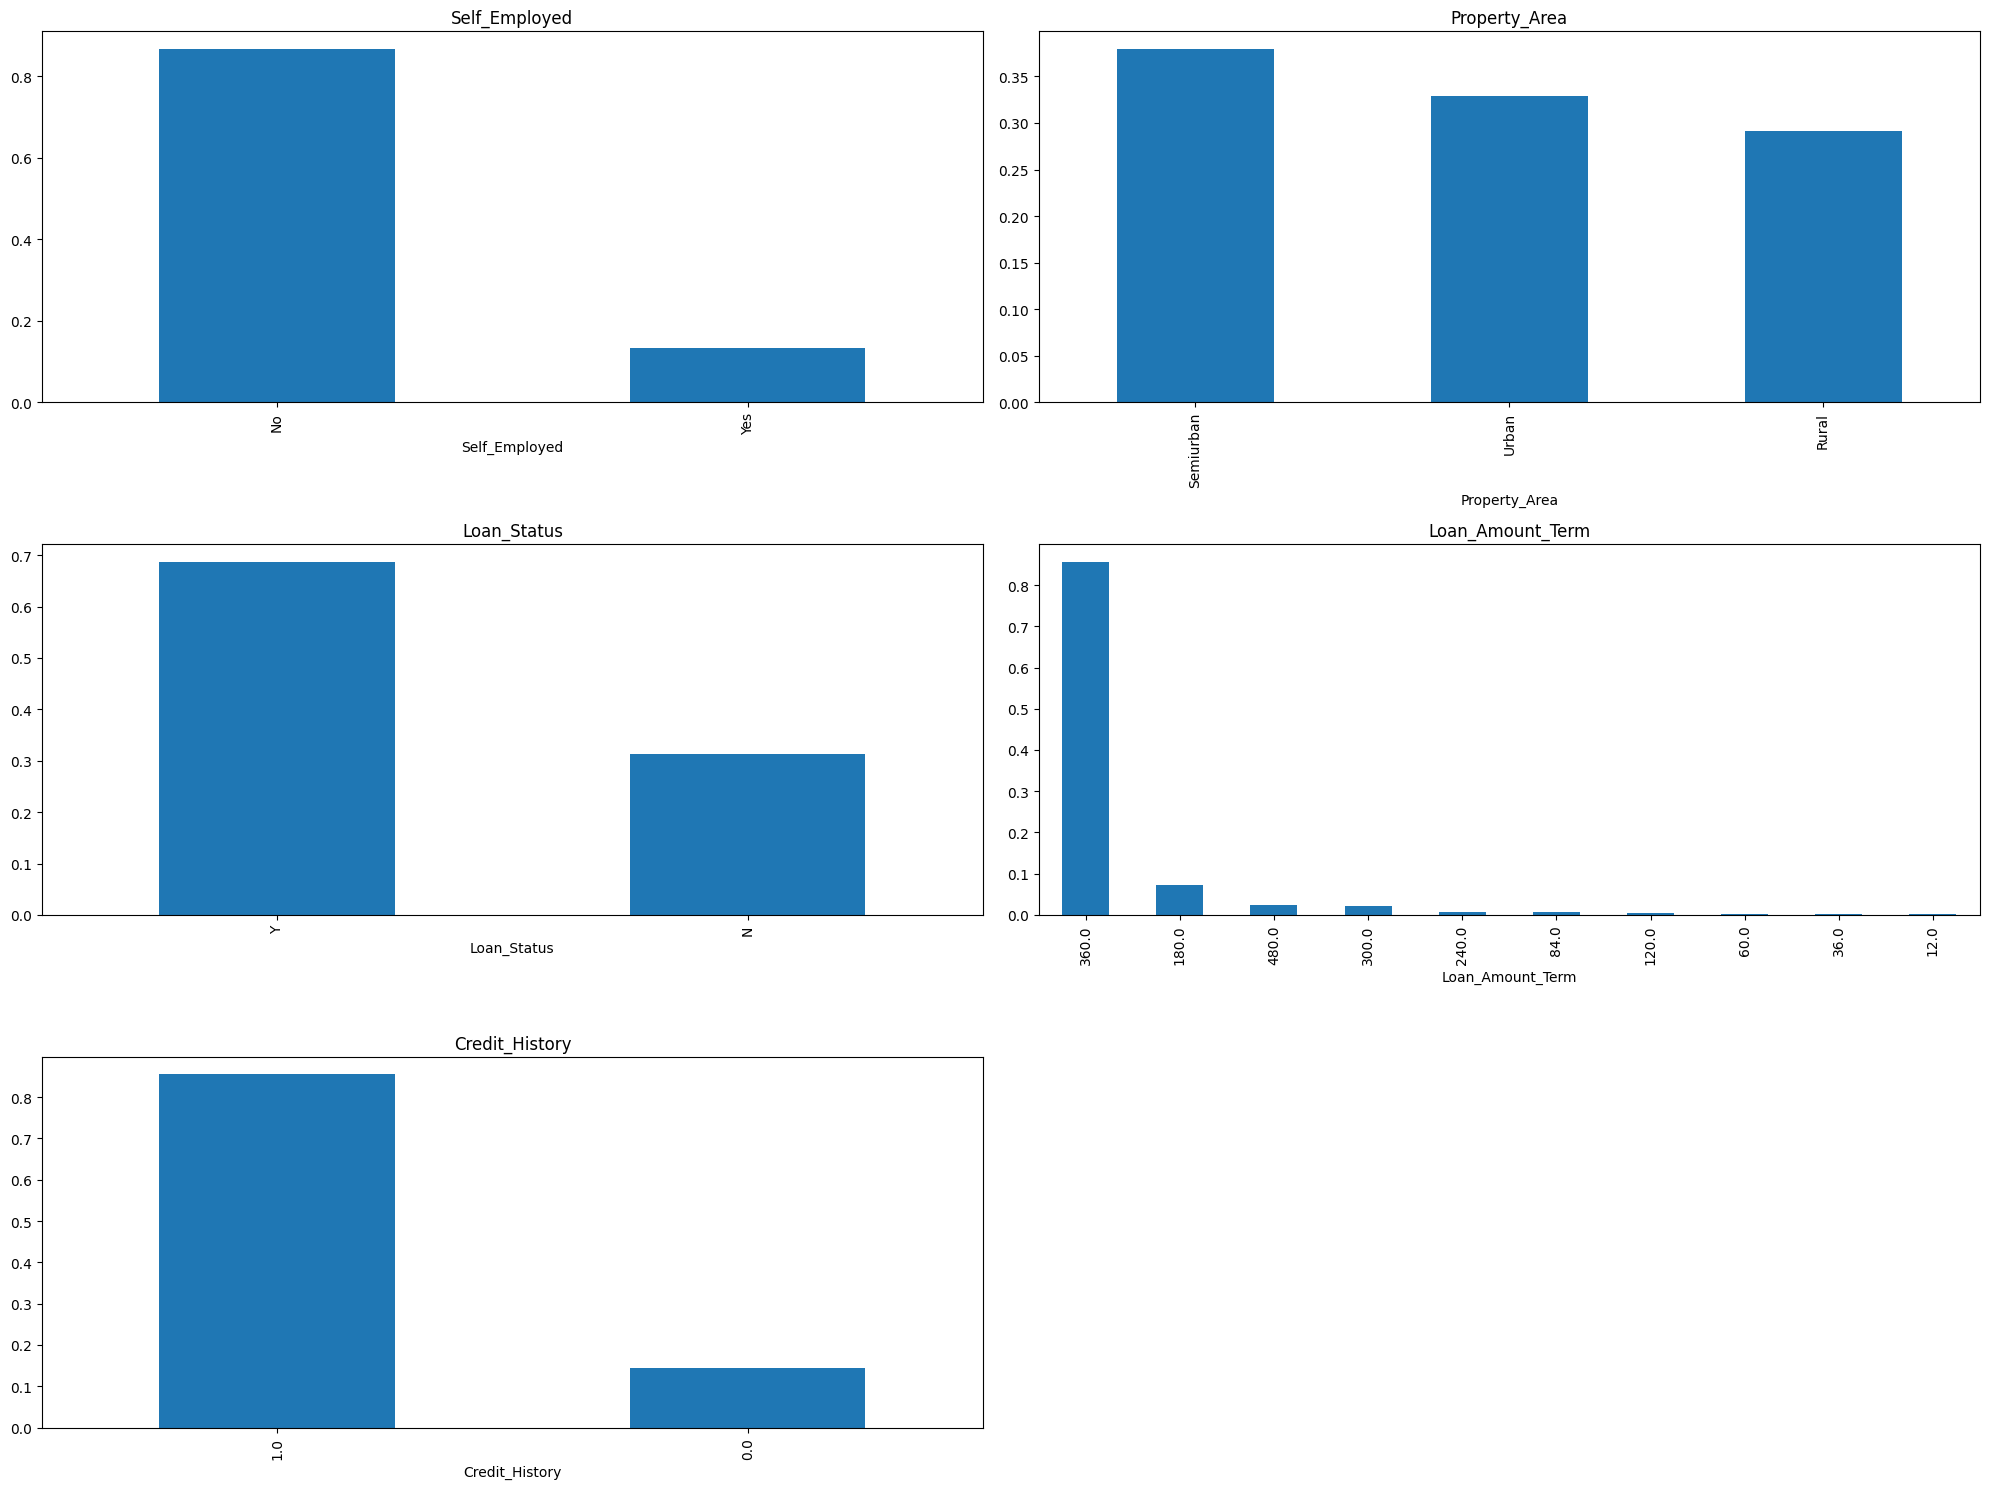

In [34]:
# categorical variable: Self_Employed/Property_Area/Loan_Status/Loan_Amount_Term/Credit_History
plt.figure(1)
plt.subplot(321)
train['Self_Employed'].value_counts(normalize=True).plot.bar(figsize=(20,15), title= 'Self_Employed')
plt.subplot(322)
train['Property_Area'].value_counts(normalize=True).plot.bar(title= 'Property_Area')
plt.subplot(323)
train['Loan_Status'].value_counts(normalize=True).plot.bar(title= 'Loan_Status')
plt.subplot(324)
train['Loan_Amount_Term'].value_counts(normalize=True).plot.bar(title= 'Loan_Amount_Term')
plt.subplot(325)
train['Credit_History'].value_counts(normalize=True).plot.bar(title= 'Credit_History')

plt.tight_layout()
plt.show()

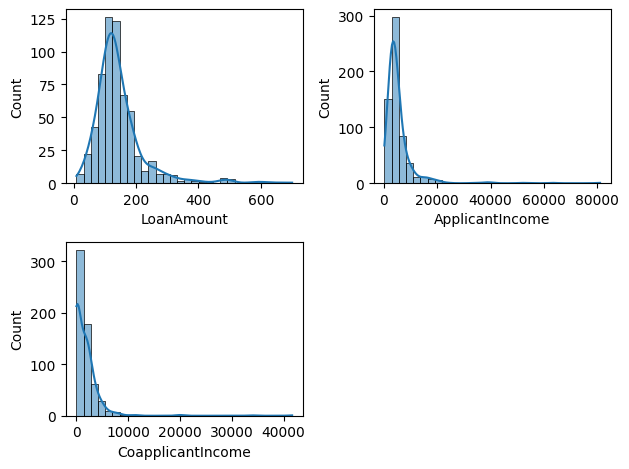

In [35]:
# numerical variable - LoanAmount/ApplicantIncome/CoapplicantIncome
plt.figure(1)
plt.subplot(221)
sns.histplot(data=train, x='LoanAmount', kde=True, bins=30)
plt.subplot(222)
sns.histplot(data=train, x='ApplicantIncome', kde=True, bins=30)
plt.subplot(223)
sns.histplot(data=train, x='CoapplicantIncome', kde=True, bins=30)

plt.tight_layout()
plt.show()

## EDA step2 - 2 dimensions - Loan_Status

<Axes: xlabel='Credit_History', ylabel='count'>

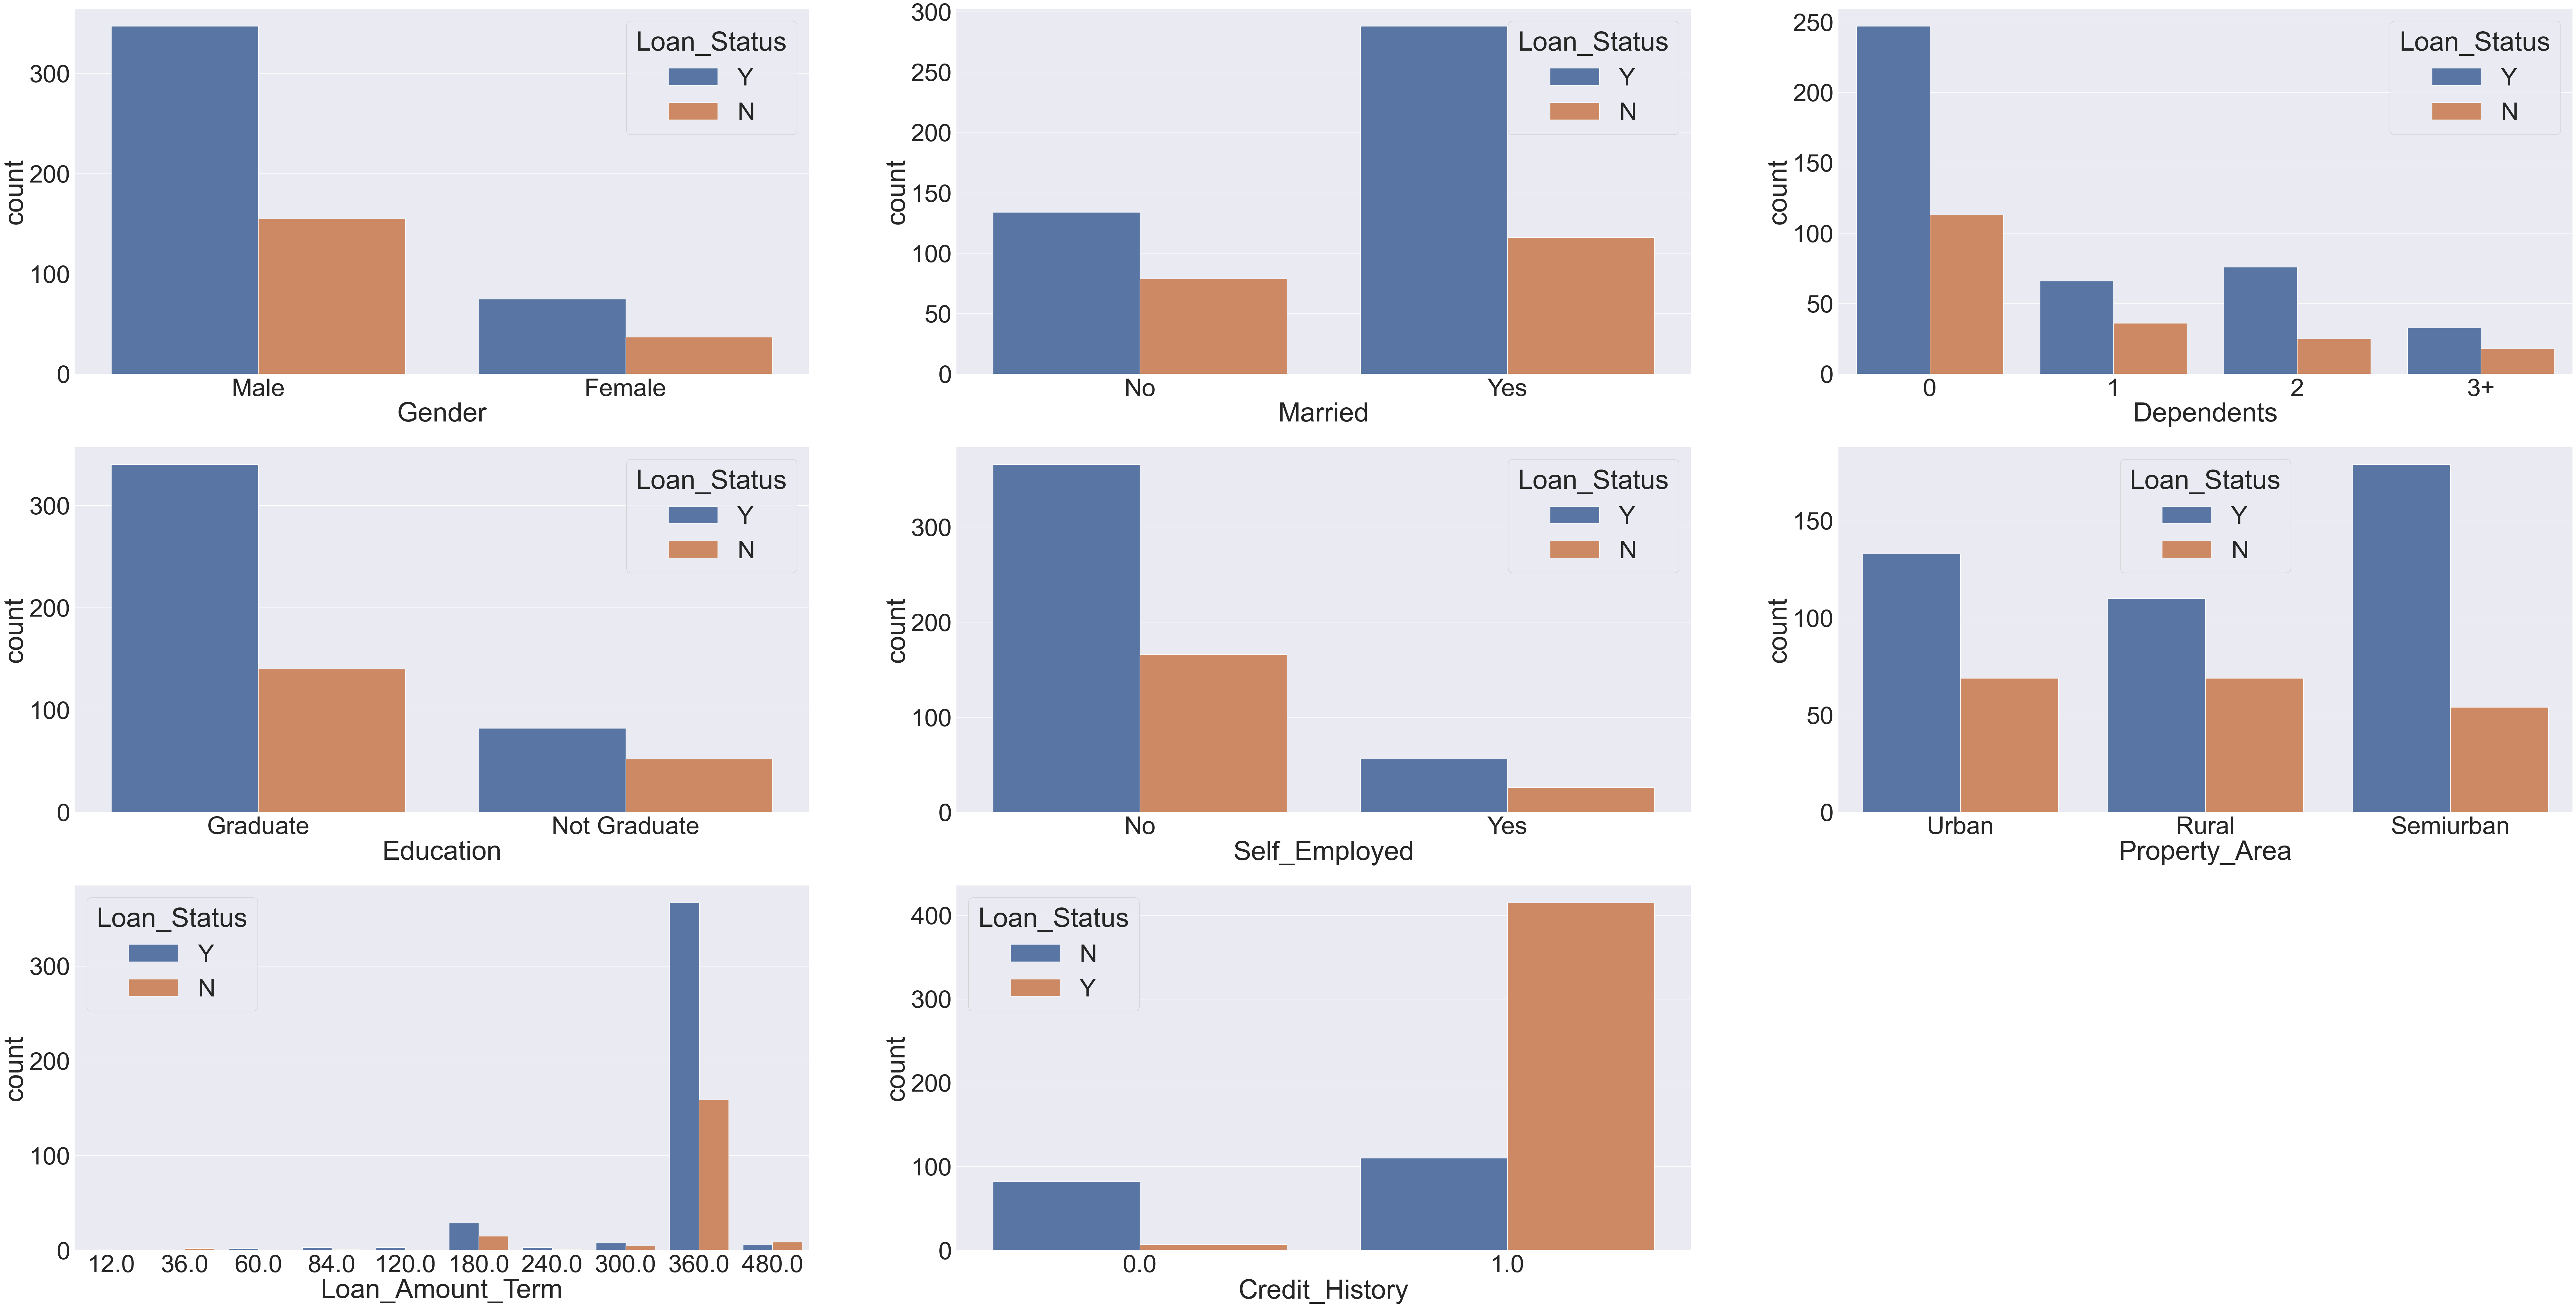

In [20]:
plt.figure(figsize=(100, 50))
sns.set(font_scale=5)

plt.subplot(331)
sns.countplot(x='Gender', hue='Loan_Status', data=train)

plt.subplot(332)
sns.countplot(x='Married', hue='Loan_Status', data=train)

plt.subplot(333)
sns.countplot(x='Dependents', hue='Loan_Status', data=train)

plt.subplot(334)
sns.countplot(x='Education', hue='Loan_Status', data=train)

plt.subplot(335)
sns.countplot(x='Self_Employed', hue='Loan_Status', data=train)

plt.subplot(336)
sns.countplot(x='Property_Area', hue='Loan_Status', data=train)

plt.subplot(337)
sns.countplot(x='Loan_Amount_Term', hue='Loan_Status', data=train)

plt.subplot(338)
sns.countplot(x='Credit_History', hue='Loan_Status', data=train)


**[ Profile of successful loan applicants: ]**  

The majority of successful loan applicants are **male**, mostly **married**, with **no or few dependents (0 or 1)**, and predominantly **university graduates**. Most are **not self-employed (Self_Employed = No)**. They typically come from **semiurban** areas, with loan terms primarily around **360 months**, and possess good credit records (**Credit_History = 1.0**).

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

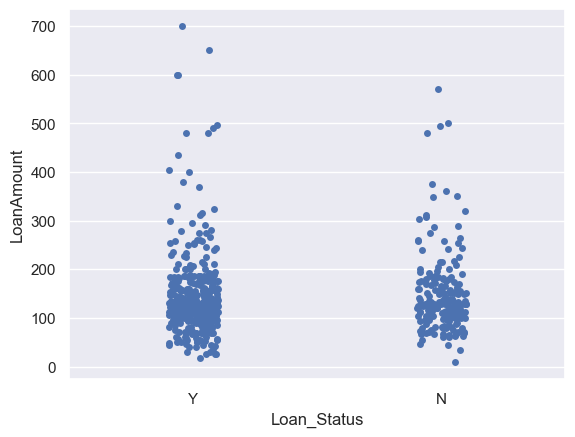

In [21]:
# Loan_Status x LoanAmount
sns.set(font_scale=1)
sns.stripplot(data=train, x="Loan_Status", y="LoanAmount", jitter=True)

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

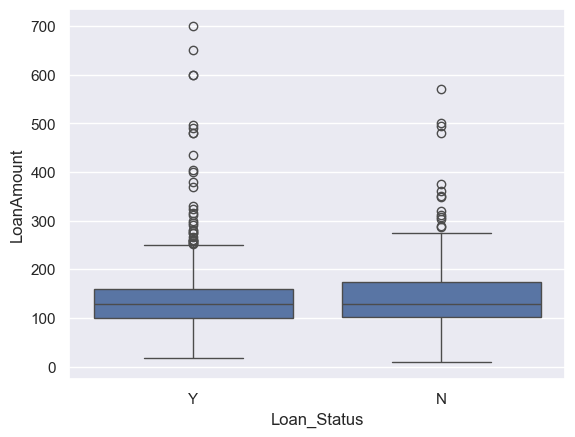

In [22]:
sns.boxplot(data=train, x="Loan_Status", y="LoanAmount")

The distributions of loan approvals (Y) and rejections (N) in terms of loan amount are very similar, and the overall LoanAmount distribution is not significantly different. Therefore, the **LoanAmount is not the decisive factor in loan approval**. Its importance may be low in subsequent models.

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

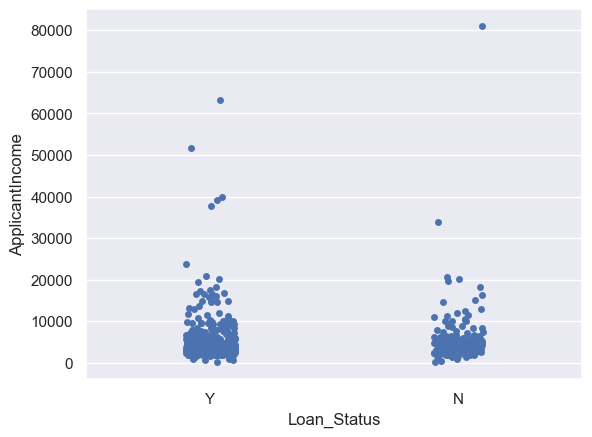

In [23]:
# Loan_Status x ApplicantIncome
sns.stripplot(data=train, x="Loan_Status", y="ApplicantIncome", jitter=True)

There was no significant difference in income distribution between successful (Y) and unsuccessful (N) loan applicants:

**Applicant income does not directly determine loan approval**; its interaction with other variables (such as credit history) is likely more crucial.

<Axes: xlabel='Loan_Status', ylabel='CoapplicantIncome'>

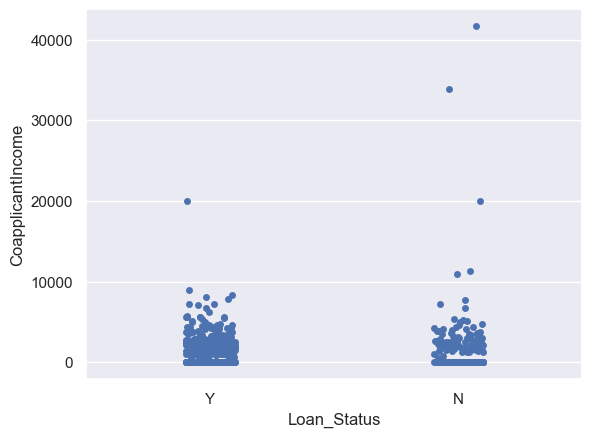

In [24]:
# Loan_Status x CoapplicantIncome
sns.stripplot(data=train, x="Loan_Status", y="CoapplicantIncome", jitter=True)

The distribution of coapplicant income differs very little between loan success (Y) and loan failure (N).

## EDA step3 - 3 dimensions - Loan_Status - Credit_History

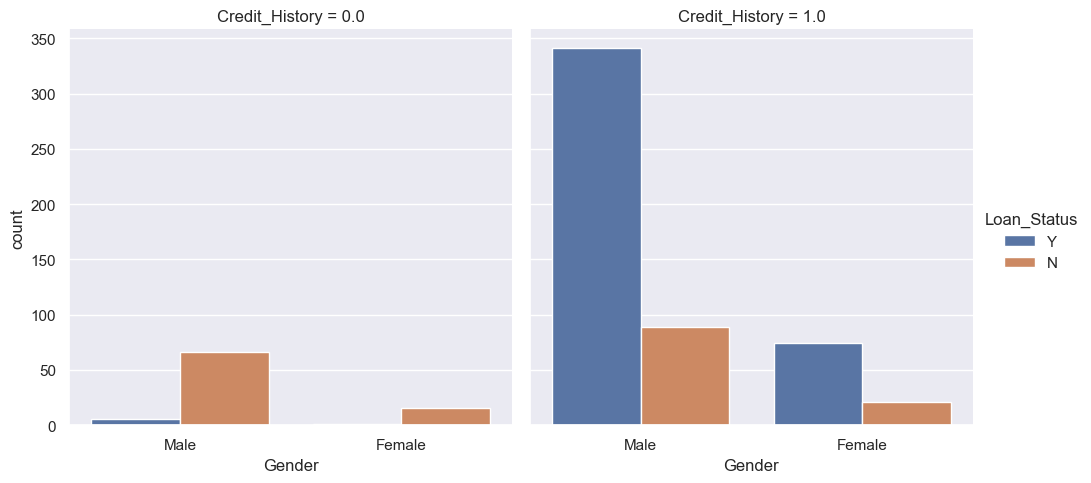

In [25]:
sns.catplot(data=train, x="Gender", hue="Loan_Status", col="Credit_History", kind="count")

Credit history has a significant impact on loan success rates, and among people with credit history, the number of **men who obtain loans is far higher than that of women**.

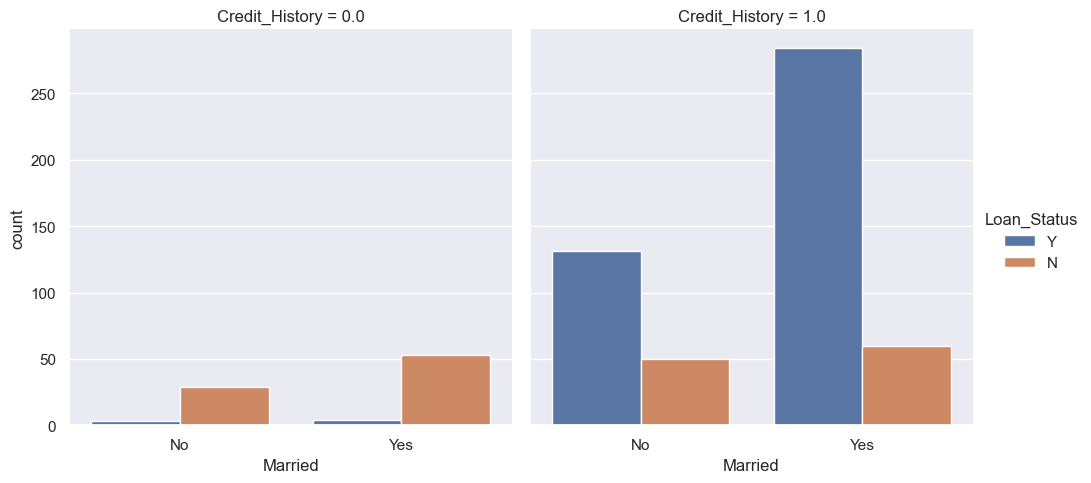

In [27]:
sns.catplot(data=train, x="Married", hue="Loan_Status", col="Credit_History", kind="count")

Among applicants with a credit history (Credit_History = 1), **married** applicants had a significantly higher loan approval rate than unmarried applicants.

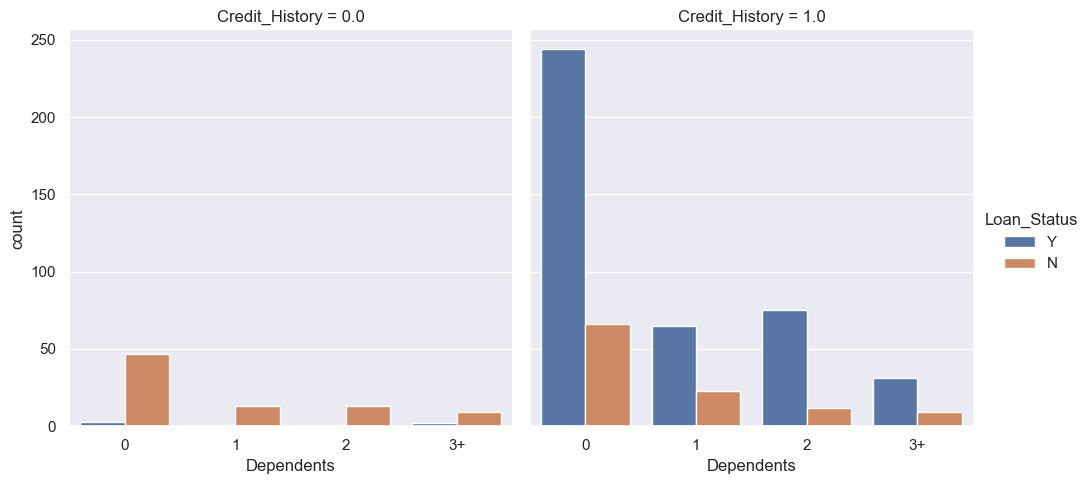

In [28]:
sns.catplot(data=train, x="Dependents", hue="Loan_Status", col="Credit_History", kind="count")

With a credit history (Credit_History = 1), the fewer dependents (especially 0), the higher the loan approval rate; however, as the number of dependents increases, the loan approval rate decreases slightly. This indicates that borrowers with **less financial burden are more likely to be approved**.

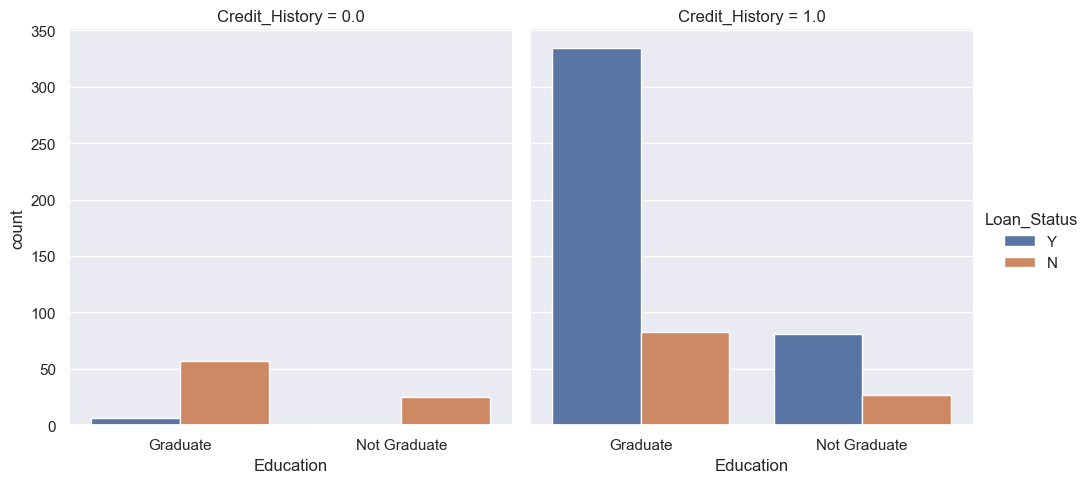

In [29]:
sns.catplot(data=train, x="Education", hue="Loan_Status", col="Credit_History", kind="count")

Assuming a credit history (Credit_History=1), the **higher education level**, the easier it is to get a loan approved.

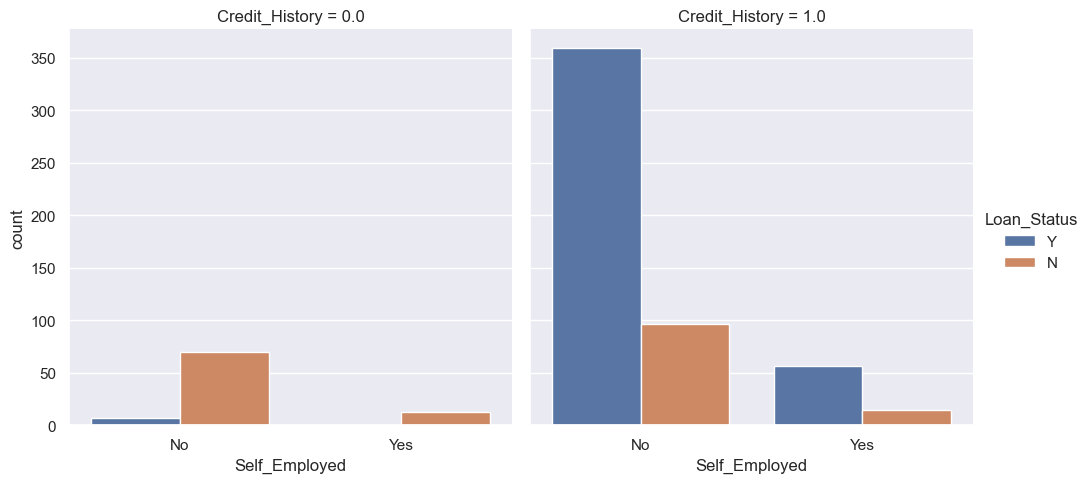

In [30]:
sns.catplot(data=train, x="Self_Employed", hue="Loan_Status", col="Credit_History", kind="count")

Assuming good credit (Credit_History = 1), **non-self-employed individuals** (Self_Employed = No) have a greater advantage.

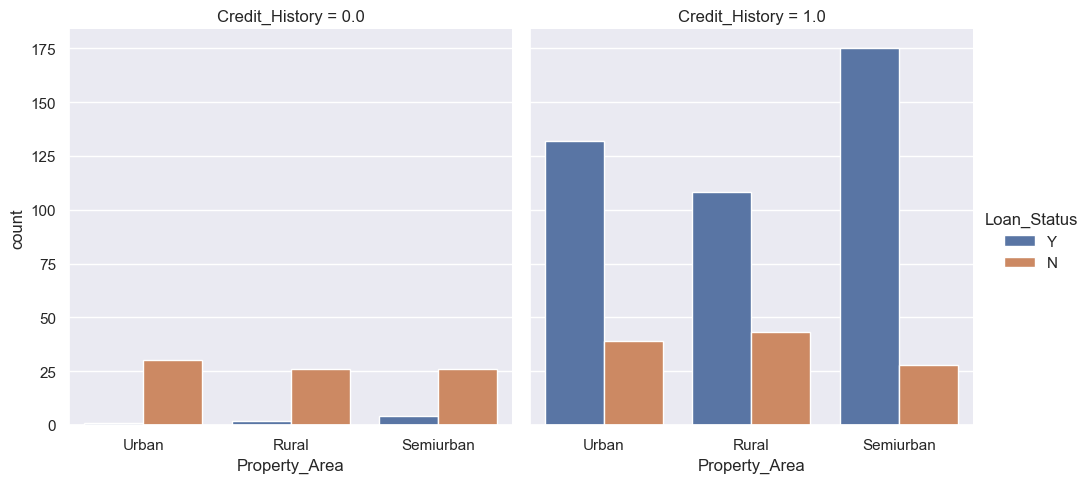

In [31]:
sns.catplot(data=train, x="Property_Area", hue="Loan_Status", col="Credit_History", kind="count")

Assuming good credit history (Credit_History = 1), Semiurban > Urban > Rural.

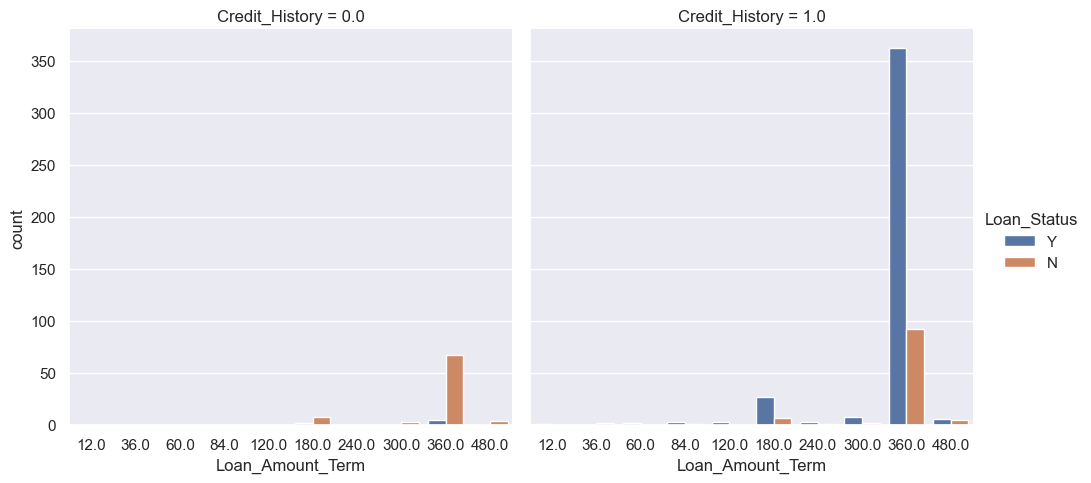

In [32]:
sns.catplot(data=train, x="Loan_Amount_Term", hue="Loan_Status", col="Credit_History", kind="count")

## EDA step4 - 4 dimensions - Loan_Status - Credit_History

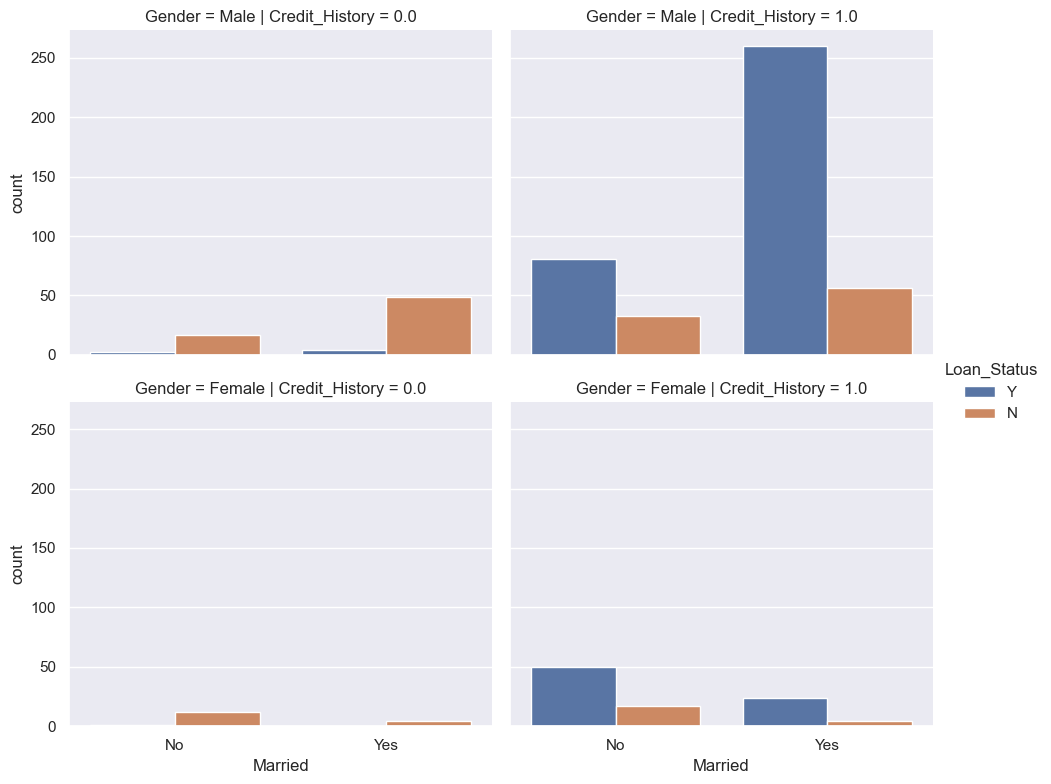

In [33]:
sns.catplot(
    data=train,
    kind='count',
    x='Married',                   
    hue='Loan_Status',             
    col='Credit_History',          
    row='Gender',                  
    height=4,
    aspect=1.2
)

plt.show()

## EDA step5 - 5 dimensions - Loan_Status - LoanAmount

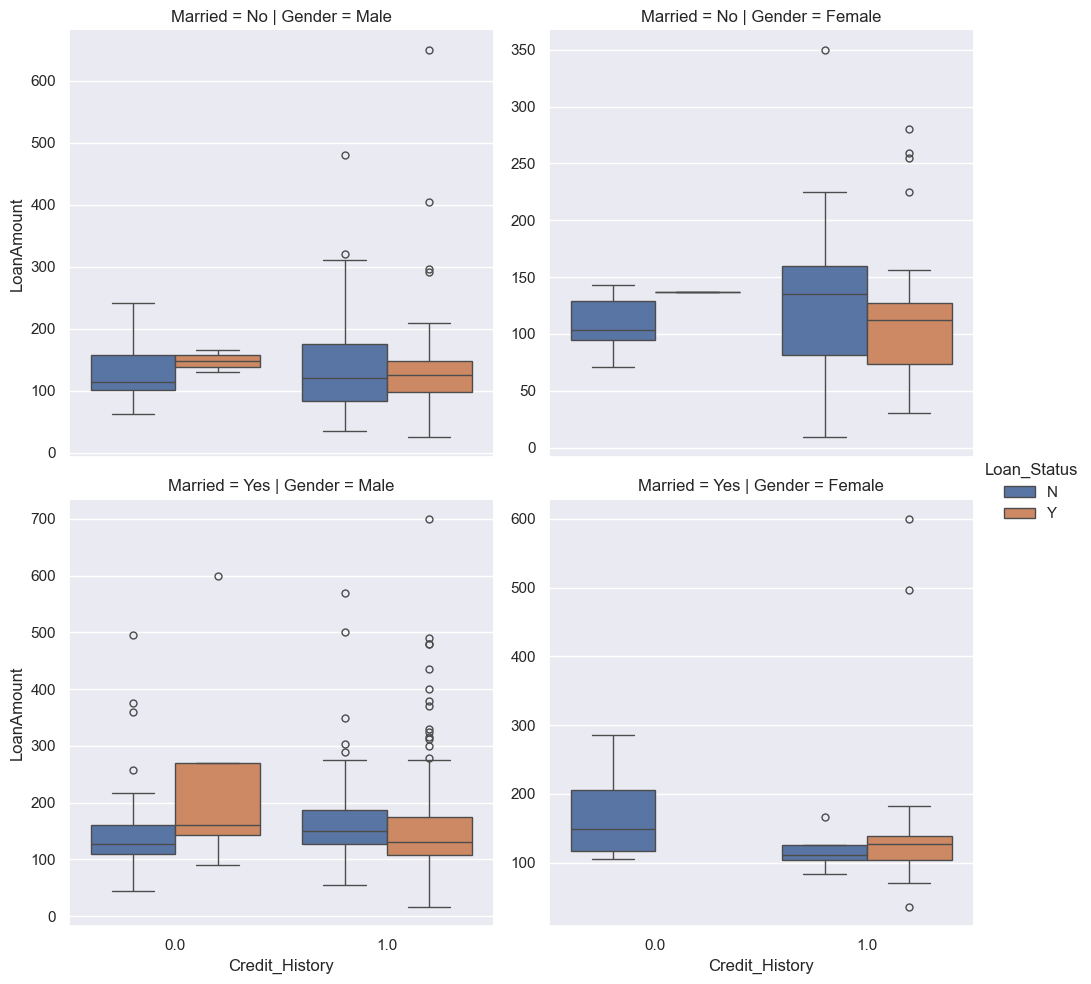

In [36]:
g = sns.catplot(
    data=train,
    x="Credit_History",
    y="LoanAmount",
    hue="Loan_Status",  
    col="Gender",   
    row="Married",
    kind="box",
    sharey=False
)

Credit history is a key factor in loan approval, and women are especially vulnerable to loan rejection when they lack a credit history.

## EDA step6 - heatmap

In [19]:
train['Loan_Status'] = train['Loan_Status'].replace({'Y': 1, 'N': 0})
print(train['Loan_Status'].unique())

[1 0]


In [20]:
train['Loan_Status'] = train['Loan_Status'].astype(float)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'ApplicantIncome'),
  Text(0, 1.5, 'CoapplicantIncome'),
  Text(0, 2.5, 'LoanAmount'),
  Text(0, 3.5, 'Loan_Amount_Term'),
  Text(0, 4.5, 'Credit_History'),
  Text(0, 5.5, 'Loan_Status')])

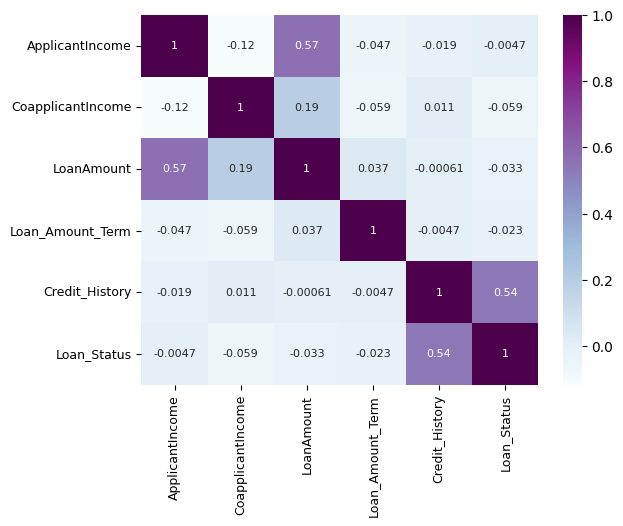

In [21]:
numeric_df = train.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='BuPu', annot_kws={'size': 8} )
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

- **Credit_History** has a moderate positive correlation with Loan Status (**0.54**), meaning a good credit history is more likely to result in loan approval;

- **ApplicantIncome** is essentially uncorrelated with loan outcomes (**-0.0047**), indicating that income itself does not determine loan approval.

# Model Building

## Feature Engineering

In [23]:
# Total Applicant Income
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1.0,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0.0,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1.0,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1.0,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1.0,6000.0


C:\Users\lengl\AppData\Local\Temp\ipykernel_18484\128231623.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['ApplicantIncomelog'])


<Axes: xlabel='ApplicantIncomelog', ylabel='Density'>

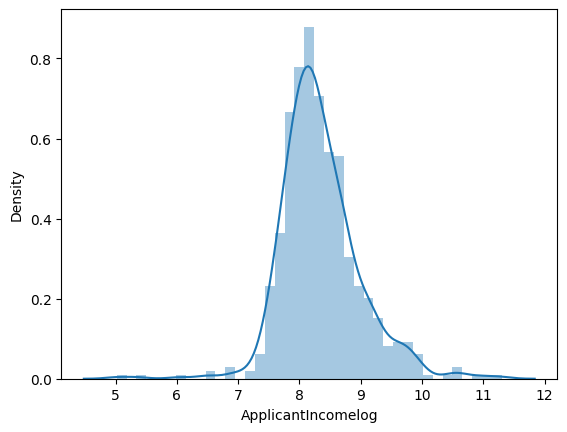

In [24]:
# Apply Log Transformation
train['ApplicantIncomelog'] = np.log(train['ApplicantIncome'] + 1)
sns.distplot(train['ApplicantIncomelog'])

In [25]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomelog
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1.0,5849.0,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0.0,6091.0,8.430327
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1.0,3000.0,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1.0,4941.0,7.857094
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1.0,6000.0,8.699681


C:\Users\lengl\AppData\Local\Temp\ipykernel_18484\2697210462.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['LoanAmountlog'])


<Axes: xlabel='LoanAmountlog', ylabel='Density'>

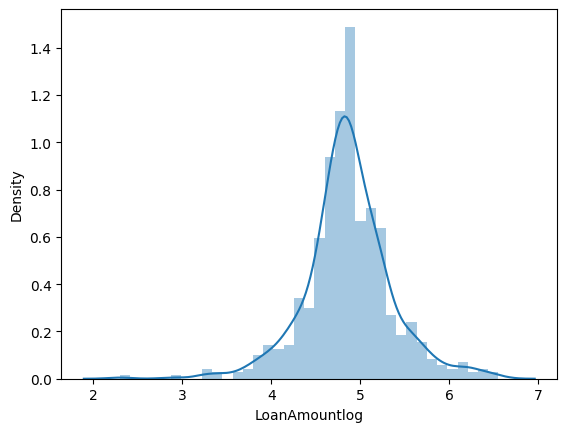

In [26]:
train['LoanAmountlog'] = np.log(train['LoanAmount'] + 1)
sns.distplot(train['LoanAmountlog'])

C:\Users\lengl\AppData\Local\Temp\ipykernel_18484\2489922927.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Loan_Amount_Term_log'])


<Axes: xlabel='Loan_Amount_Term_log', ylabel='Density'>

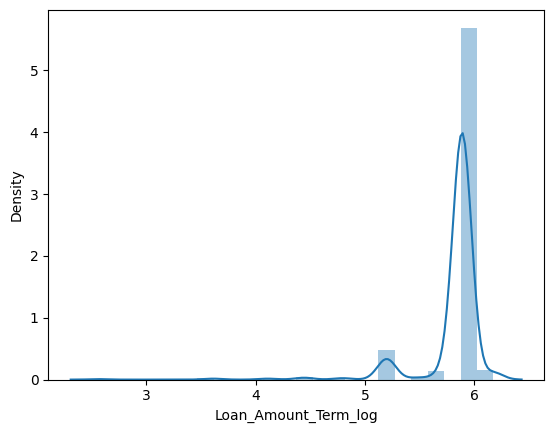

In [27]:
train['Loan_Amount_Term_log'] = np.log(train['Loan_Amount_Term'] + 1)
sns.distplot(train['Loan_Amount_Term_log'])

C:\Users\lengl\AppData\Local\Temp\ipykernel_18484\2949882142.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Total_Income_log'])


<Axes: xlabel='Total_Income_log', ylabel='Density'>

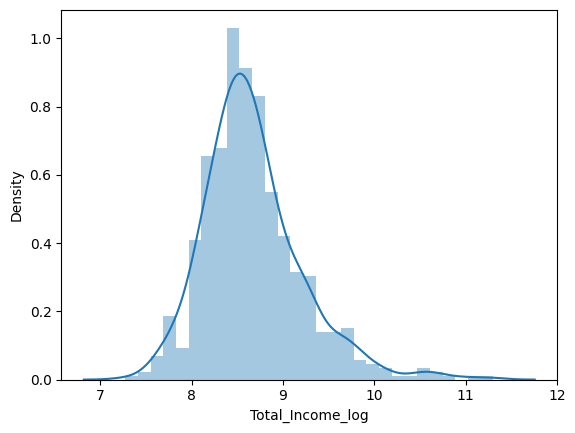

In [28]:
train['Total_Income_log'] = np.log(train['Total_Income'] + 1)
sns.distplot(train['Total_Income_log'])

In [29]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1.0,5849.0,8.674197,4.859812,5.888878,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0.0,6091.0,8.430327,4.859812,5.888878,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1.0,3000.0,8.006701,4.204693,5.888878,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1.0,4941.0,7.857094,4.795791,5.888878,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1.0,6000.0,8.699681,4.955827,5.888878,8.699681


In [30]:
# Drop unnecessary columns
cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Total_Income','Loan_ID']
train = train.drop(columns = cols)
train.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,Male,No,0,Graduate,No,1.0,Urban,1.0,8.674197,4.859812,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.0,Rural,0.0,8.430327,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.0,Urban,1.0,8.006701,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.0,Urban,1.0,7.857094,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.0,Urban,1.0,8.699681,4.955827,5.888878,8.699681


In [31]:
# Encoding Technique : Label Encoding, One Hot Encoding

from sklearn.preprocessing import LabelEncoder
cols = ['Gender','Married','Education','Dependents','Self_Employed','Property_Area','Loan_Status']
le =  LabelEncoder()
for col in cols:
  train[col] =  le.fit_transform(train[col])

In [32]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,1,8.674197,4.859812,5.888878,8.674197
1,1,1,1,0,0,1.0,0,0,8.430327,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,1,8.006701,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,1,7.857094,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,1,8.699681,4.955827,5.888878,8.699681


In [33]:
train.dtypes

Gender                    int64
Married                   int64
Dependents                int64
Education                 int64
Self_Employed             int64
Credit_History          float64
Property_Area             int64
Loan_Status               int64
ApplicantIncomelog      float64
LoanAmountlog           float64
Loan_Amount_Term_log    float64
Total_Income_log        float64
dtype: object

In [34]:
# Split Independent and dependent features

X = train.drop(columns = ['Loan_Status'])
y = train['Loan_Status']

In [35]:
X

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,8.674197,4.859812,5.888878,8.674197
1,1,1,1,0,0,1.0,0,8.430327,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,8.006701,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,7.857094,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,8.699681,4.955827,5.888878,8.699681
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,1.0,0,7.972811,4.276666,5.888878,7.972811
610,1,1,3,0,0,1.0,0,8.320448,3.713572,5.198497,8.320448
611,1,1,1,0,0,1.0,2,8.996280,5.537334,5.888878,9.025576
612,1,1,2,0,0,1.0,2,8.933796,5.236442,5.888878,8.933796


In [36]:
y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

In [39]:
# Logistic Regression
model1 = LogisticRegression()
model1.fit(X_train,y_train)
y_pred_model1 = model1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model1)

In [40]:
accuracy*100

77.27272727272727

In [41]:
# Accuracy : the ratio of the correctly predicted values to total values
score = cross_val_score(model1,X,y,cv=5)
score

array([0.81300813, 0.7804878 , 0.7804878 , 0.85365854, 0.81967213])

In [42]:
np.mean(score)*100

np.float64(80.9462881514061)

In [43]:
# Decision Tree Classifier

model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)
y_pred_model2 = model2.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model2)
print("Accuracy score of Decision Tree: ", accuracy*100)

Accuracy score of Decision Tree:  70.77922077922078


In [44]:
score = cross_val_score(model2,X,y,cv=5)
print("Cross Validation score of Decision Tree: ",np.mean(score)*100)

Cross Validation score of Decision Tree:  69.70678395308542


In [45]:
# Random Forest Classifier
model3 = RandomForestClassifier()
model3.fit(X_train,y_train)
y_pred_model3 = model3.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model3)
print("Accuracy score of Random Forest: ", accuracy*100)

Accuracy score of Random Forest:  75.97402597402598


In [46]:
#KNearestNeighbors model
model4 = KNeighborsClassifier(n_neighbors=3)
model4.fit(X_train,y_train)
y_pred_model4 = model4.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model4)
print("Accuracy score of KNeighbors: ", accuracy*100)

Accuracy score of KNeighbors:  71.42857142857143


In [47]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name,y_test,y_pred):
  report = classification_report(y_test,y_pred)
  print(f"Classification Report For {model_name}:\n{report}\n")

generate_classification_report(model1,y_test,y_pred_model1)
generate_classification_report(model2,y_test,y_pred_model2)
generate_classification_report(model3,y_test,y_pred_model3)
generate_classification_report(model4,y_test,y_pred_model4)

Classification Report For LogisticRegression():
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154


Classification Report For DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        54
           1       0.75      0.82      0.78       100

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Classification Report For RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.77      0.44      0.56        54
           1       0.76      0.93      0.83       100

    accuracy                

In [49]:
train['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [50]:
pip install -U imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from imblearn.over_sampling import RandomOverSampler

In [52]:
oversample = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X,y)

df_resampled = pd.concat([pd.DataFrame(X_resampled,columns=X.columns),pd.Series(y_resampled,name="Loan_status")],axis=1)

In [53]:
X_resampled

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,LoanAmountlog,Loan_Amount_Term_log,Total_Income_log
0,1,0,0,0,0,1.0,2,8.674197,4.859812,5.888878,8.674197
1,1,1,1,0,0,1.0,0,8.430327,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,8.006701,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,7.857094,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,8.699681,4.955827,5.888878,8.699681
...,...,...,...,...,...,...,...,...,...,...,...
839,1,1,3,1,0,1.0,2,8.292298,4.859812,5.198497,8.292298
840,1,1,1,0,0,1.0,0,7.539559,4.127134,5.888878,7.539559
841,1,1,1,0,0,0.0,0,7.933080,4.990433,5.888878,8.456381
842,1,1,2,1,0,0.0,2,7.969012,3.828641,5.198497,7.969012


In [54]:
y_resampled

0      1
1      0
2      1
3      1
4      1
      ..
839    0
840    0
841    0
842    0
843    0
Name: Loan_Status, Length: 844, dtype: int64

In [55]:
y_resampled.value_counts()

Loan_Status
1    422
0    422
Name: count, dtype: int64

In [56]:
X_resampled_train, X_resampled_test, y_resampled_train, y_resampled_test = train_test_split(X_resampled,y_resampled,test_size = 0.25,random_state=42)

In [57]:
# Logistic Regression
model1 = LogisticRegression()
model1.fit(X_resampled_train,y_resampled_train)
y_pred_model1 = model1.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model1)
accuracy*100

C:\Users\lengl\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


68.24644549763033

In [58]:
# Decision Tree Classifier
model2 = DecisionTreeClassifier()
model2.fit(X_resampled_train,y_resampled_train)
y_pred_model2 = model2.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model2)
print("Accuracy score of Decision Tree: ", accuracy*100)

Accuracy score of Decision Tree:  79.62085308056872


In [59]:
# Random Forest Classifier
model3 = RandomForestClassifier()
model3.fit(X_resampled_train,y_resampled_train)
y_pred_model3 = model3.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model3)
print("Accuracy score of Random Forest: ", accuracy*100)

Accuracy score of Random Forest:  88.62559241706161


In [60]:
# KNearestNeighbors model
model4 = KNeighborsClassifier(n_neighbors=3)
model4.fit(X_resampled_train,y_resampled_train)
y_pred_model4 = model4.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model4)
print("Accuracy score of KNeighbors: ", accuracy*100)

Accuracy score of KNeighbors:  72.03791469194313


In [61]:
from sklearn.metrics import classification_report

def generate_classification_report(model_name,y_test,y_pred):
  report = classification_report(y_test,y_pred)
  print(f"Classification Report For {model_name}:\n{report}\n")

generate_classification_report(model1,y_resampled_test,y_pred_model1)
generate_classification_report(model2,y_resampled_test,y_pred_model2)
generate_classification_report(model3,y_resampled_test,y_pred_model3)
generate_classification_report(model4,y_resampled_test,y_pred_model4)

Classification Report For LogisticRegression():
              precision    recall  f1-score   support

           0       0.82      0.53      0.64       114
           1       0.61      0.87      0.71        97

    accuracy                           0.68       211
   macro avg       0.72      0.70      0.68       211
weighted avg       0.72      0.68      0.68       211


Classification Report For DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       114
           1       0.81      0.73      0.77        97

    accuracy                           0.80       211
   macro avg       0.80      0.79      0.79       211
weighted avg       0.80      0.80      0.80       211


Classification Report For RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       114
           1       0.85      0.92      0.88        97

    accuracy                

## Grid search -> hyparameter tuning

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [66]:
clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=clf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',  
                           n_jobs=-1)  

In [67]:
grid_search.fit(X_resampled, y_resampled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [68]:
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
best_model = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.9040715694561848


This is the best-performing combination in the `param_grid`:  
- `max_depth=None`: The tree can expand indefinitely until a leaf node is pure or contains the minimum number of samples;  

- `min_samples_split=2`: A node is eligible for further splitting if it has ≥ 2 samples;  

- `n_estimators=100`: 100 trees are used in the forest.

## Feature Importance

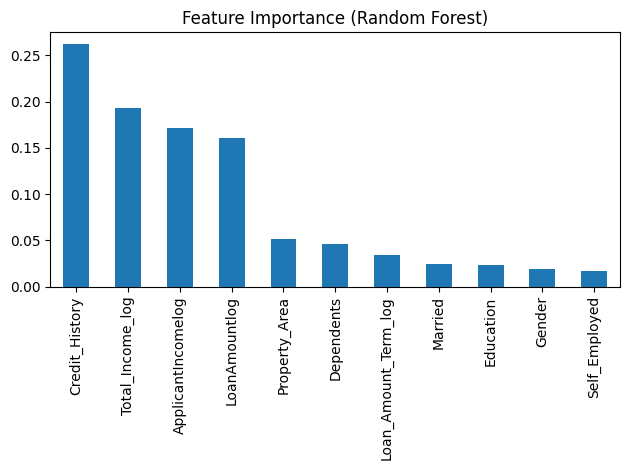

In [70]:
feature_importances = pd.Series(model3.feature_importances_, index=X_resampled_train.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

- **`Credit_history`** is the most important factor in predicting loan approval → It can be used for risk control policy design.

- **`Income-related`** characteristics also rank highly → It is recommended that business units focus on the authenticity of income and supporting documentation.

- Gender and Self-Employed have the least impact → They contribute little to model predictions; simplifying their data collection in business operations could be considered.